In [65]:
fig.write_image(
    "../reports/charts/sector_allocation.png"
)

print("Sector chart saved")

Sector chart saved


# EDA Findings

1. NAV values showed overall growth trends across selected mutual fund schemes from 2022-2026.

2. Equity mutual funds contributed significantly to overall market growth.

3. AUM increased consistently across major fund houses.

4. SIP inflows showed a positive long-term growth pattern.

5. Large-cap funds showed relatively stable NAV movement.

6. Fund categories had different inflow patterns across months.

7. Folio count increased from 13.26 Cr to higher levels during the analysis period.

8. Different mutual funds showed varying correlation in daily returns.

9. Banking, Utilities, Pharma and other sectors contributed major portfolio allocation.

10. Sector diversification helped reduce concentration risk.

In [63]:
print(holdings.head())

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [62]:
print(holdings.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [64]:
import plotly.express as px

sector_summary = holdings.groupby(
    "sector"
)["weight_pct"].sum().reset_index()


fig = px.pie(
    sector_summary,
    names="sector",
    values="weight_pct",
    hole=0.4,
    title="Sector Allocation Across Equity Funds"
)

fig.show()

In [60]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(holdings.head())
print(holdings.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [59]:
plt.savefig(
    "../reports/charts/nav_correlation.png",
    bbox_inches="tight"
)

print("Correlation chart saved")

Correlation chart saved


<Figure size 640x480 with 0 Axes>

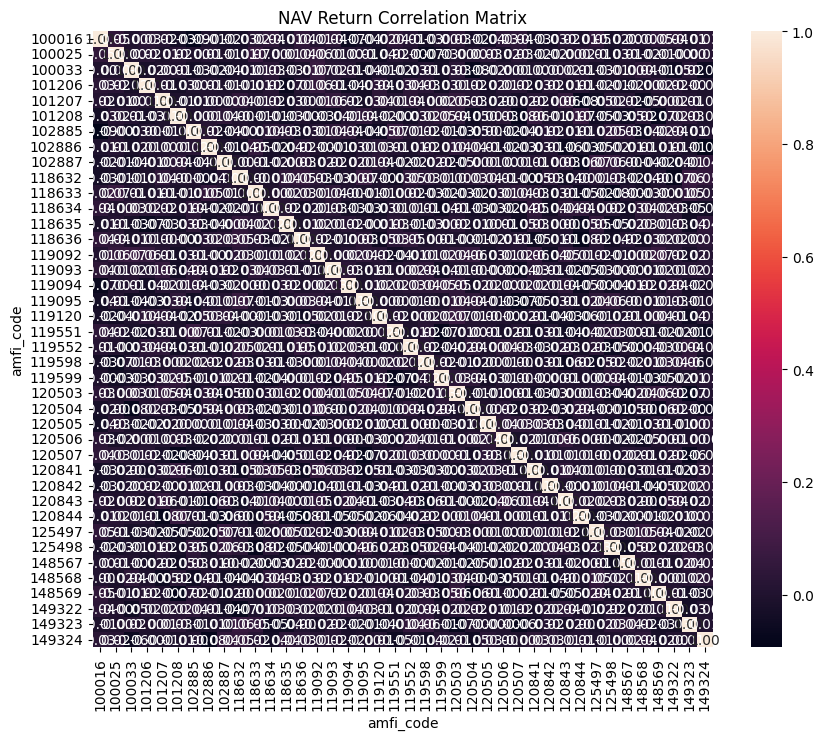

In [58]:
corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

In [57]:
returns = nav_table.pct_change()

print(returns.head())

amfi_code     100016    100025    100033    101206    101207    101208  \
date                                                                     
2022-01-03       NaN       NaN       NaN       NaN       NaN       NaN   
2022-01-04 -0.010306 -0.003553 -0.013328  0.001153 -0.010865 -0.000141   
2022-01-05  0.012865 -0.000050 -0.004386  0.003866  0.000603  0.000382   
2022-01-06 -0.011377 -0.001880 -0.005167 -0.002128 -0.029101 -0.000143   
2022-01-07 -0.001210  0.002036 -0.005748 -0.006314  0.024766  0.000215   

amfi_code     102885    102886    102887    118632  ...    120843    120844  \
date                                                ...                       
2022-01-03       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2022-01-04  0.011122  0.011314 -0.010459 -0.000714  ...  0.018160  0.000243   
2022-01-05 -0.007878  0.006779 -0.005308  0.005913  ... -0.012304  0.000462   
2022-01-06  0.015277  0.031127  0.012678  0.003540  ...  0.008509  0.000650   
2022-01

In [56]:
nav_table = nav_history.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

print(nav_table.head())

amfi_code     100016   100025    100033    101206   101207    101208   102885  \
date                                                                            
2022-01-03  520.4608  26.3169  107.3758  305.0996  38.5736  310.7415  89.8728   
2022-01-04  515.0971  26.2234  105.9447  305.4514  38.1545  310.6977  90.8724   
2022-01-05  521.7239  26.2221  105.4800  306.6324  38.1775  310.8165  90.1565   
2022-01-06  515.7880  26.1728  104.9350  305.9800  37.0665  310.7719  91.5338   
2022-01-07  515.1639  26.2261  104.3318  304.0480  37.9845  310.8388  90.6762   

amfi_code     102886    102887   118632  ...   120843     120844    125497  \
date                                     ...                                 
2022-01-03  119.2905  191.0721  42.8339  ...  49.9131  3180.6318  560.1443   
2022-01-04  120.6402  189.0737  42.8033  ...  50.8195  3181.4042  560.7052   
2022-01-05  121.4580  188.0701  43.0564  ...  50.1942  3182.8754  563.0884   
2022-01-06  125.2386  190.4545  43.2088  .

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

nav_history = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

print(nav_history.head())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


In [54]:
plt.savefig(
    "../reports/charts/folio_growth.png",
    bbox_inches="tight"
)

print("Folio chart saved")

Folio chart saved


<Figure size 640x480 with 0 Axes>

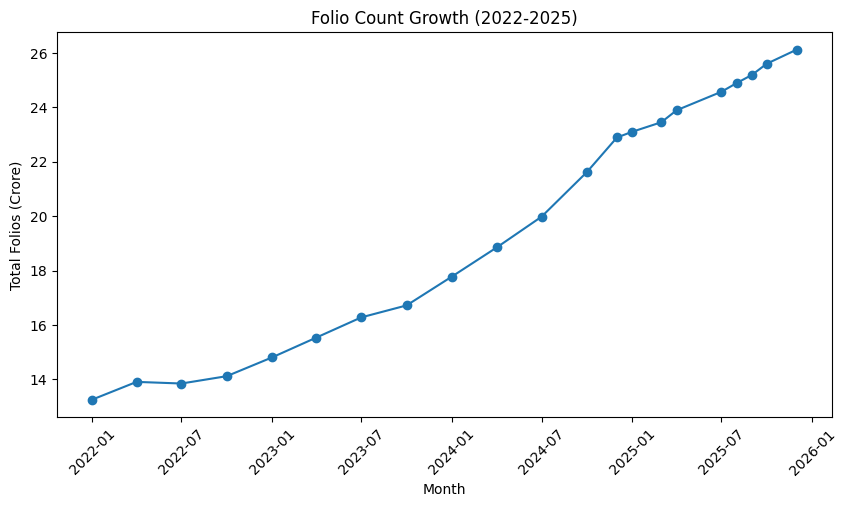

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

folio = investor   # using your loaded file

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(10,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Folio Count Growth (2022-2025)")

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.show()

In [52]:
print(investor.head())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


In [51]:
print(investor.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


In [50]:
age_count = investor["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_count,
    labels=age_count.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

KeyError: 'age_group'

In [49]:
investor = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

print(investor.head())
print(investor.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')


In [47]:
plt.savefig(
    "../reports/charts/category_heatmap.png",
    bbox_inches="tight"
)

print("Heatmap saved")

Heatmap saved


<Figure size 640x480 with 0 Axes>

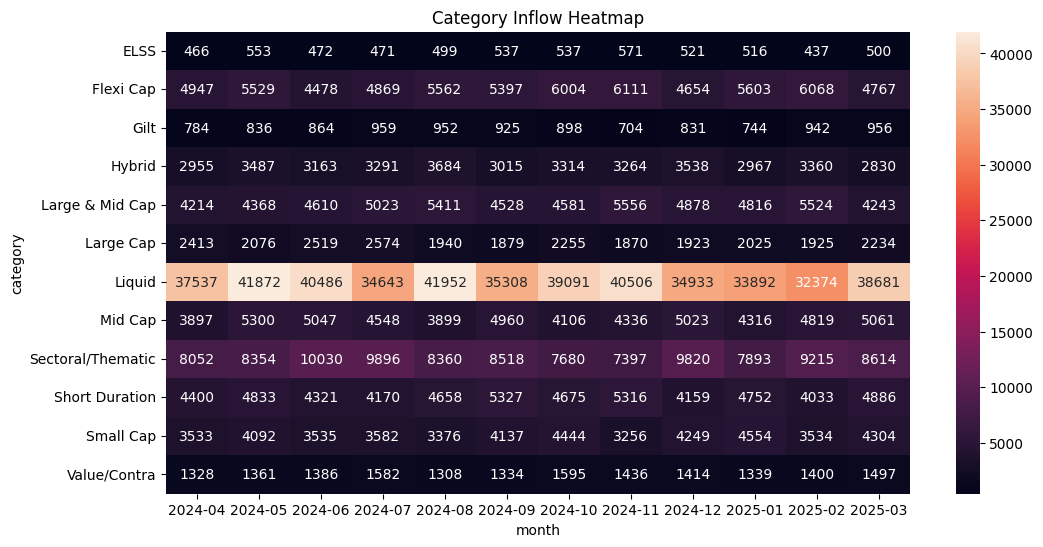

In [46]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heat,
    annot=True,
    fmt=".0f"
)

plt.title("Category Inflow Heatmap")

plt.show()

In [44]:
print(category.head())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [43]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='object')


In [45]:
heat = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

print(heat.head())

month            2024-04  2024-05  2024-06  2024-07  2024-08  2024-09  \
category                                                                
ELSS               466.0    553.0    472.0    471.0    499.0    537.0   
Flexi Cap         4947.0   5529.0   4478.0   4869.0   5562.0   5397.0   
Gilt               784.0    836.0    864.0    959.0    952.0    925.0   
Hybrid            2955.0   3487.0   3163.0   3291.0   3684.0   3015.0   
Large & Mid Cap   4214.0   4368.0   4610.0   5023.0   5411.0   4528.0   

month            2024-10  2024-11  2024-12  2025-01  2025-02  2025-03  
category                                                               
ELSS               537.0    571.0    521.0    516.0    437.0    500.0  
Flexi Cap         6004.0   6111.0   4654.0   5603.0   6068.0   4767.0  
Gilt               898.0    704.0    831.0    744.0    942.0    956.0  
Hybrid            3314.0   3264.0   3538.0   2967.0   3360.0   2830.0  
Large & Mid Cap   4581.0   5556.0   4878.0   4816.0   55

In [41]:
category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

print(category.head())
print(category.columns)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='object')


In [40]:
fig.write_image(
    "../reports/charts/sip_trend.png"
)

print("SIP chart saved")

SIP chart saved


In [39]:
fig = px.line(
    sip,
    x="month",
    y=sip.select_dtypes(include="number").columns[0],
    title="Monthly SIP Inflow Trend (2022-2025)"
)

fig.show()

In [38]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

print(sip.dtypes)

month                        datetime64[ns]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object


In [37]:
print(sip.head())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [36]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


In [35]:
sip["date"] = pd.to_datetime(
    sip["date"]
)

print(sip.dtypes)

KeyError: 'date'

In [33]:
import os

files = os.listdir("../data/raw")

print(files)

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'HDFC_Top100_Live_NAV.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_LargeCap.csv', 'SBI_Bluechip.csv']


In [34]:
sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

print(sip.head())
print(sip.columns)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')


In [31]:
plt.savefig(
    "../reports/charts/aum_growth.png",
    bbox_inches="tight"
)

print("AUM chart saved")

AUM chart saved


<Figure size 640x480 with 0 Axes>

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='object')
Using column: aum_lakh_crore


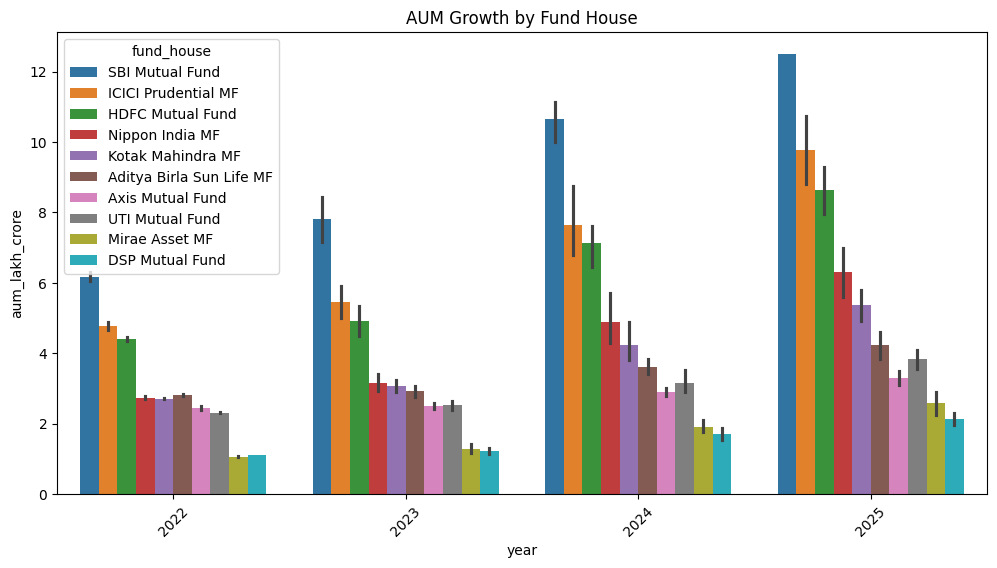

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# show columns
print(aum.columns)

# take the numeric column automatically
num_col = aum.select_dtypes(
    include="number"
).columns[0]

print("Using column:", num_col)


plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y=num_col,
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.show()

In [29]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']


In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.show()

ValueError: Could not interpret value `aum` for `y`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [27]:
print(aum.columns)
print(aum.head())

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='object')
        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


In [24]:
print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


In [23]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes',
       'year'],
      dtype='object')


In [21]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

print(aum.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

print(aum.head())
print(aum.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [19]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [16]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [14]:
aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

print(aum.head())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [11]:
aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

print(aum.head())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [10]:
import os

os.makedirs(
    "../reports/charts",
    exist_ok=True
)

fig.write_image(
    "../reports/charts/nav_trend.png"
)

print("NAV chart saved successfully")

Resorting to unclean kill browser.


NAV chart saved successfully


In [9]:
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (2022-2026)"
)

fig.show()

In [8]:
import pandas as pd
import plotly.express as px

nav_history = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

print("NAV data loaded")

NAV data loaded


In [6]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

print(nav_history.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


In [5]:
print("Fund Master Shape:")
print(fund_master.shape)

print("NAV History Shape:")
print(nav_history.shape)

Fund Master Shape:
(40, 15)
NAV History Shape:
(46000, 3)


In [4]:
print("Fund Master Data")

print(fund_master.head())


print("NAV History Data")

print(nav_history.head())

Fund Master Data
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_

In [3]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav_history = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

In [2]:
path = "../data/raw/"

files = os.listdir(path)

print(files)

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'HDFC_Top100_Live_NAV.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_LargeCap.csv', 'SBI_Bluechip.csv']


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import os

print("EDA Started")

EDA Started
